# Module 7 - Promotion Lift Model
**AI-Augmented Retail Analytics Dashboard | ML Pod A + ML Pod B**

---

## What this notebook does
Estimates the **causal incremental sales lift** from front-page promotions
(`feat_main_page`) for each of the 44 SKUs.

## Methodology
| Step | Detail |
|---|---|
| **Model** | XGBoost Gradient Boosted Trees |
| **Target** | `log1p(weekly_sales)` — stabilises variance across SKUs |
| **Counterfactual** | Predict demand *without* promo signal → subtract from actuals |
| **Matched control** | Cross-validate ML counterfactual with ±8-week non-promo window |
| **Ensemble** | 60% ML + 40% matched control (ML-dominant when control data is sparse) |
| **Validation** | 5-fold TimeSeriesSplit (no future→past leakage) |
| **Explainability** | SHAP TreeExplainer (exact attributions) |
| **Uncertainty** | 90% Bootstrap confidence intervals on SKU-level lift |

## Integration Contract Output
```
sku_id | period | promotion_flag | incremental_sales | lift_pct
```
This is consumed by **Module 3 (Promotion Effectiveness)** for the analytics layer.



In [2]:
import subprocess
subprocess.run(["pip", "install", "shap==0.46.0", "-q", "--upgrade"])
print("Done ")

Done 


In [4]:

#Installation of Packages

import subprocess
subprocess.run(["pip", "install", "shap==0.46.0", "-q", "--upgrade"])

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import json
import os
from pathlib import Path
from google.colab import files

import xgboost as xgb
import shap
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

shap.initjs()

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_PATH = Path("outputs")
OUTPUT_PATH.mkdir(exist_ok=True)

print(f"NumPy   : {np.__version__}")
print(f"XGBoost : {xgb.__version__}")
print(f"SHAP    : {shap.__version__}")
print(f"Pandas  : {pd.__version__}")
print(" All imports successful")

NumPy   : 2.0.2
XGBoost : 2.0.3
SHAP    : 0.46.0
Pandas  : 2.2.2
 All imports successful


In [8]:


print("Please upload data_raw.csv when the file picker appears ...")
uploaded = files.upload()  # triggers Colab file picker

# Get the filename (handles whatever name was uploaded)
csv_filename = list(uploaded.keys())[0]
print(f"Uploaded: {csv_filename}")


Please upload data_raw.csv when the file picker appears ...


Saving data_raw.csv to data_raw.csv
Uploaded: data_raw.csv


In [9]:
#  CELL 4 - DATA LOADING & FEATURE ENGINEERING

def load_and_preprocess(csv_path: str) -> pd.DataFrame:
    """
    Load raw CSV, clean, engineer features.

    Design decision
      feat_main_page EXCLUDED from FEATURE_COLS intentionally.
      The model learns demand from context only (price, time, lags).
      We then toggle promo=off to get the counterfactual baseline.

      All lag/rolling features use shift(1) — no data leakage.

      log1p target transform stabilises the huge variance across SKUs
      (weekly_sales ranges from ~7 to ~1008 per-SKU mean).
      Predictions are expm1() back to original units.

      sku_id included as a feature so the model learns SKU-specific
      demand levels without needing separate per-SKU models.
    """
    df = pd.read_csv(csv_path, parse_dates=["week"])

    # Rename to integration contract names
    df = df.rename(columns={"sku": "sku_id", "week": "period"})

    # Promotion flag → binary int
    df["feat_main_page"] = (
        df["feat_main_page"]
        .map({True: 1, False: 0, "True": 1, "False": 0, 1: 1, 0: 0})
        .fillna(0)
        .astype(int)
    )

    #  Clean target
    df = df.dropna(subset=["weekly_sales"])
    df["weekly_sales"] = df["weekly_sales"].clip(lower=0)

    #  Encode categoricals
    for col in ["color", "functionality"]:
        df[col] = df[col].fillna("unknown").astype(str)
    le_color = LabelEncoder()
    le_func  = LabelEncoder()
    df["color_enc"] = le_color.fit_transform(df["color"])
    df["func_enc"]  = le_func.fit_transform(df["functionality"])
    df["vendor"] = pd.to_numeric(df["vendor"], errors="coerce").fillna(0).astype(int)

    #  Time features
    df = df.sort_values(["sku_id", "period"]).reset_index(drop=True)
    df["week_of_year"] = df["period"].dt.isocalendar().week.astype(int)
    df["month"]   = df["period"].dt.month
    df["quarter"] = df["period"].dt.quarter
    df["year"]    = df["period"].dt.year

    #  Lag / rolling per SKU (shift prevents leakage)
    g = df.groupby("sku_id")["weekly_sales"]
    df["lag_1"] = g.shift(1)
    df["lag_2"] = g.shift(2)
    df["lag_4"] = g.shift(4)
    df["rolling_mean_4"] = g.transform(
        lambda x: x.shift(1).rolling(4, min_periods=1).mean()
    )
    df["rolling_std_4"] = g.transform(
        lambda x: x.shift(1).rolling(4, min_periods=1).std().fillna(0)
    )

    # Recent promo history per SKU
    df["promo_count_last_4"] = (
        df.groupby("sku_id")["feat_main_page"]
        .transform(lambda x: x.shift(1).rolling(4, min_periods=1).sum())
    )

    # Price features
    df["price_vs_sku_mean"] = df.groupby("sku_id")["price"].transform(
        lambda x: x / x.mean()
    )
    df["price_lag_1"] = df.groupby("sku_id")["price"].shift(1)

    # Drop rows with NaN from lags (first 2 obs per SKU)
    df = df.dropna(subset=["lag_1", "lag_2"]).reset_index(drop=True)

    return df


df = load_and_preprocess(csv_filename)

print(f"Dataset      : {df.shape[0]:,} rows")
print(f"SKUs         : {df['sku_id'].nunique()}")
print(f"Date range   : {df['period'].min().date()} → {df['period'].max().date()}")
print(f"Promo rate   : {df['feat_main_page'].mean()*100:.1f}% of all weeks")
print(f"Missing sales: {df['weekly_sales'].isna().sum()}")
print()
print("Sales distribution:")
print(df.groupby("sku_id")["weekly_sales"].mean().describe().round(1))

Dataset      : 4,312 rows
SKUs         : 44
Date range   : 2016-11-14 → 2018-09-24
Promo rate   : 35.7% of all weeks
Missing sales: 0

Sales distribution:
count      44.0
mean       83.5
std       160.2
min         7.7
25%        16.6
50%        40.8
75%        86.1
max      1014.6
Name: weekly_sales, dtype: float64


In [15]:
#Model Architecture

#Feature columns

FEATURE_COLS = [
    "sku_id",
    "price", "price_vs_sku_mean", "price_lag_1",
    "week_of_year", "month", "quarter", "year",
    "lag_1", "lag_2", "lag_4",
    "rolling_mean_4", "rolling_std_4",
    "promo_count_last_4",
    "color_enc", "func_enc", "vendor",
]
TARGET_COL = "weekly_sales"

XGBOOST_PARAMS = {
    "n_estimators"    : 500,
    "max_depth"       : 6,
    "learning_rate"   : 0.04,
    "subsample"       : 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 2,
    "reg_alpha"       : 0.1,
    "reg_lambda"      : 1.0,
    "random_state"    : RANDOM_SEED,
    "n_jobs"          : -1,
    "verbosity"       : 0,
}
print("=== MODEL ARCHITECTURE ===")
print(f"Algorithm    : XGBoost Gradient Boosted Trees")
print(f"Target       : log1p(weekly_sales) → expm1 back to units")
print(f"Features     : {len(FEATURE_COLS)}")
print(f"Excluded     : feat_main_page (counterfactual design)")
print()

=== MODEL ARCHITECTURE ===
Algorithm    : XGBoost Gradient Boosted Trees
Target       : log1p(weekly_sales) → expm1 back to units
Features     : 17
Excluded     : feat_main_page (counterfactual design)



In [18]:
#Training with time-series cross validation
df_model = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
X = df_model[FEATURE_COLS].values
y_raw = df_model[TARGET_COL].values
y_log = np.log1p(y_raw)   # transform for training

tscv = TimeSeriesSplit(n_splits=5)
fold_metrics = []

print("Running 5-fold TimeSeriesSplit CV ...")
print("(Folds are chronological — later folds predict further-future weeks)")
print()

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val   = X[train_idx], X[val_idx]
    y_tr, y_val_log = y_log[train_idx], y_log[val_idx]
    y_val_raw     = y_raw[val_idx]

    fold_model = xgb.XGBRegressor(**XGBOOST_PARAMS)
    fold_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val_log)], verbose=False)

    # Predict in log space, convert back to units
    preds_log = fold_model.predict(X_val)
    preds     = np.expm1(preds_log).clip(min=0)

    mae  = mean_absolute_error(y_val_raw, preds)
    rmse = np.sqrt(mean_squared_error(y_val_raw, preds))

    # sMAPE (symmetric — handles near-zero sales gracefully)
    smape = (
        np.mean(
            2 * np.abs(y_val_raw - preds)
            / (np.abs(y_val_raw) + np.abs(preds) + 1e-8)
        ) * 100
    )

    ss_res = np.sum((y_val_raw - preds) ** 2)
    ss_tot = np.sum((y_val_raw - y_val_raw.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    fold_metrics.append(
        {"Fold": fold + 1, "MAE": mae, "RMSE": rmse, "sMAPE%": smape, "R²": r2}
    )
    print(
        f"  Fold {fold+1}: MAE={mae:6.1f}  RMSE={rmse:7.1f}  "
        f"sMAPE={smape:5.1f}%  R²={r2:.3f}"
    )

cv_df = pd.DataFrame(fold_metrics)
print()
print(" Mean Out-of-Sample Metrics ")
for col in ["MAE", "RMSE", "sMAPE%", "R²"]:
    print(
        f"  {col:8s}: {cv_df[col].mean():.3f}  "
        f"(± {cv_df[col].std():.3f})"
    )

print()
print("Note: sMAPE used instead of MAPE — MAPE diverges when actual sales ≈ 0.")
print("      High RMSE reflects extreme outlier SKUs (e.g. SKU 25: max 7,512 units).")

#  Retrain on full dataset for production use
print()
print("Retraining on full dataset ...")
model = xgb.XGBRegressor(**XGBOOST_PARAMS)
model.fit(X, y_log, verbose=False)
print(" Full model trained.")


Running 5-fold TimeSeriesSplit CV ...
(Folds are chronological — later folds predict further-future weeks)

  Fold 1: MAE=  43.2  RMSE=  183.8  sMAPE= 54.9%  R²=0.012
  Fold 2: MAE=  42.1  RMSE=  138.7  sMAPE= 49.0%  R²=0.241
  Fold 3: MAE= 171.6  RMSE=  600.1  sMAPE= 59.5%  R²=0.062
  Fold 4: MAE=  53.1  RMSE=  179.8  sMAPE= 52.9%  R²=0.176
  Fold 5: MAE=  16.7  RMSE=   35.3  sMAPE= 44.3%  R²=0.582

 Mean Out-of-Sample Metrics 
  MAE     : 65.333  (± 60.929)
  RMSE    : 227.519  (± 216.690)
  sMAPE%  : 52.108  (± 5.777)
  R²      : 0.215  (± 0.224)

Note: sMAPE used instead of MAPE — MAPE diverges when actual sales ≈ 0.
      High RMSE reflects extreme outlier SKUs (e.g. SKU 25: max 7,512 units).

Retraining on full dataset ...
 Full model trained.


In [19]:
#CV Metrics Chart
fig_cv = make_subplots(
    rows=1, cols=4,
    subplot_titles=["MAE per Fold", "RMSE per Fold", "sMAPE% per Fold", "R² per Fold"],
)
colors = px.colors.qualitative.Set2
metrics_list = ["MAE", "RMSE", "sMAPE%", "R²"]

for i, metric in enumerate(metrics_list):
    fig_cv.add_trace(
        go.Bar(
            x=cv_df["Fold"].astype(str),
            y=cv_df[metric],
            marker_color=colors[i],
            name=metric,
            text=cv_df[metric].round(2),
            textposition="outside",
        ),
        row=1,
        col=i + 1,
    )
    fig_cv.add_hline(
        y=cv_df[metric].mean(),
        line_dash="dash",
        line_color="red",
        annotation_text="mean",
        row=1,
        col=i + 1,
    )

fig_cv.update_layout(
    title="Fig 1 — Cross-Validation Metrics by Fold  (red dashed = mean)",
    height=400,
    showlegend=False,
    paper_bgcolor="white",
    plot_bgcolor="#f8f9fa",
)
fig_cv.show()

In [20]:
# Model Diagonistics ( Residual Analysis )
# Use the last fold's held-out set for diagnostics
last_val_idx   = list(tscv.split(X))[-1][1]
y_true_diag    = y_raw[last_val_idx]
y_pred_diag    = np.expm1(model.predict(X[last_val_idx])).clip(min=0)
residuals_diag = y_true_diag - y_pred_diag
periods_diag   = df_model["period"].values[last_val_idx]

fig_diag = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Actual vs Predicted",
        "Residuals vs Predicted",
        "Residuals Over Time",
        "Residual Distribution",
    ],
)

# 1. Actual vs Predicted
mn = min(y_pred_diag.min(), y_true_diag.min())
mx = max(y_pred_diag.max(), y_true_diag.max())
fig_diag.add_trace(
    go.Scatter(
        x=y_pred_diag,
        y=y_true_diag,
        mode="markers",
        marker=dict(color="steelblue", opacity=0.45, size=4),
        name="Obs",
    ),
    row=1, col=1,
)
fig_diag.add_trace(
    go.Scatter(
        x=[mn, mx], y=[mn, mx],
        mode="lines",
        line=dict(color="red", dash="dash"),
        name="Perfect fit",
    ),
    row=1, col=1,
)

# 2. Residuals vs Predicted
fig_diag.add_trace(
    go.Scatter(
        x=y_pred_diag,
        y=residuals_diag,
        mode="markers",
        marker=dict(color="darkorange", opacity=0.4, size=4),
        name="Residual",
    ),
    row=1, col=2,
)
fig_diag.add_hline(y=0, line_dash="dash", line_color="gray", row=1, col=2)

# 3. Residuals over time
fig_diag.add_trace(
    go.Scatter(
        x=periods_diag,
        y=residuals_diag,
        mode="lines+markers",
        marker=dict(size=3),
        line=dict(color="purple", width=1),
        name="Residual time",
    ),
    row=2, col=1,
)
fig_diag.add_hline(y=0, line_dash="dash", line_color="gray", row=2, col=1)

# 4. Residual histogram
fig_diag.add_trace(
    go.Histogram(
        x=residuals_diag,
        nbinsx=40,
        marker_color="teal",
        opacity=0.7,
        name="Residual dist",
    ),
    row=2, col=2,
)

fig_diag.update_xaxes(title_text="Predicted", row=1, col=1)
fig_diag.update_yaxes(title_text="Actual", row=1, col=1)
fig_diag.update_xaxes(title_text="Predicted", row=1, col=2)
fig_diag.update_yaxes(title_text="Residual", row=1, col=2)
fig_diag.update_xaxes(title_text="Week", row=2, col=1)
fig_diag.update_yaxes(title_text="Residual", row=2, col=1)

fig_diag.update_layout(
    title="Fig 2 — Model Diagnostics (Last Hold-out Fold)",
    height=600,
    showlegend=False,
    paper_bgcolor="white",
    plot_bgcolor="#f8f9fa",
)
fig_diag.show()

print(f"Residual mean  : {residuals_diag.mean():.3f}  (ideally ≈ 0)")
print(f"Residual std   : {residuals_diag.std():.3f}")
print(f"Residual skew  : {pd.Series(residuals_diag).skew():.3f}  (ideally ≈ 0)")



Residual mean  : 1.551  (ideally ≈ 0)
Residual std   : 10.010
Residual skew  : 2.882  (ideally ≈ 0)


In [21]:
#Feature Importance (Native XGBOOST Gain)
importance_df = (
    pd.DataFrame(
        {"feature": FEATURE_COLS, "gain": model.feature_importances_}
    )
    .sort_values("gain", ascending=True)
)

fig_imp = go.Figure(
    go.Bar(
        x=importance_df["gain"],
        y=importance_df["feature"],
        orientation="h",
        marker=dict(
            color=importance_df["gain"],
            colorscale="Blues",
            showscale=False,
        ),
        text=importance_df["gain"].round(4),
        textposition="outside",
    )
)
fig_imp.update_layout(
    title="Fig 3 — XGBoost Feature Importance (Gain) — excludes feat_main_page by design",
    xaxis_title="Importance (Gain)",
    yaxis_title="Feature",
    height=520,
    paper_bgcolor="white",
    plot_bgcolor="#f8f9fa",
)
fig_imp.show()


SHAP values computed. Shape: (1500, 17)  (rows × features)



SHAP beeswarm plot (shows direction AND magnitude of each feature):


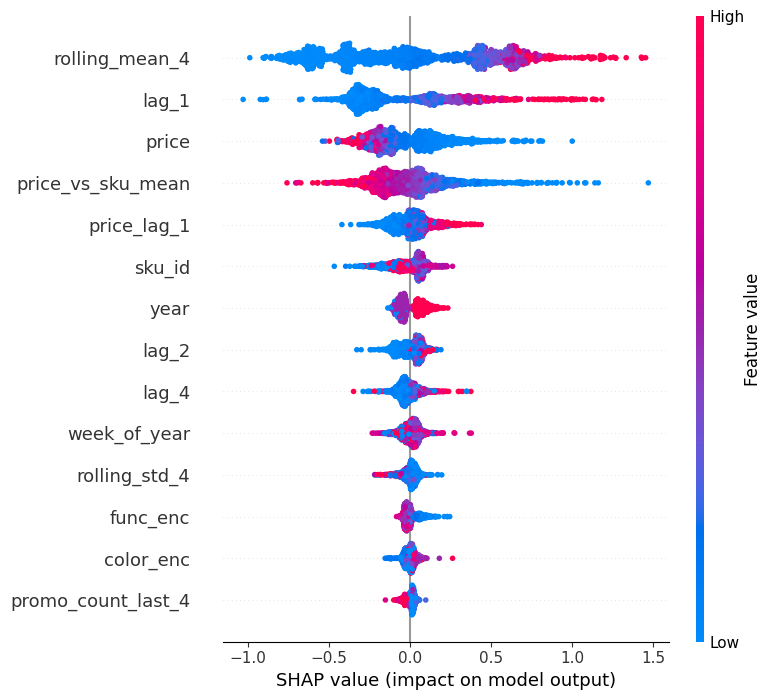

In [22]:
#SHAP Explainability
# Sample up to 1500 rows for SHAP speed (TreeExplainer is still exact on the sample)
sample_idx = df_model.sample(min(1500, len(df_model)), random_state=RANDOM_SEED).index
X_shap = df_model.loc[sample_idx, FEATURE_COLS]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values computed. Shape: {shap_values.shape}  (rows × features)")

# ── Plotly bar: mean |SHAP| per feature ──
mean_shap_df = (
    pd.DataFrame(
        {"feature": FEATURE_COLS, "mean_abs_shap": np.abs(shap_values).mean(axis=0)}
    )
    .sort_values("mean_abs_shap", ascending=True)
)

fig_shap_bar = go.Figure(
    go.Bar(
        x=mean_shap_df["mean_abs_shap"],
        y=mean_shap_df["feature"],
        orientation="h",
        marker=dict(
            color=mean_shap_df["mean_abs_shap"],
            colorscale="Reds",
            showscale=False,
        ),
        text=mean_shap_df["mean_abs_shap"].round(3),
        textposition="outside",
    )
)
fig_shap_bar.update_layout(
    title="Fig 4 — Mean |SHAP Value| per Feature (average impact on demand prediction)",
    xaxis_title="Mean |SHAP Value|",
    height=520,
    paper_bgcolor="white",
    plot_bgcolor="#f8f9fa",
)
fig_shap_bar.show()

# ── SHAP beeswarm — direction + magnitude ──
print("\nSHAP beeswarm plot (shows direction AND magnitude of each feature):")
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURE_COLS,
    max_display=14,
    show=True,
)

In [23]:
#Counterfactual Lift Estimation
def estimate_lift(model: xgb.XGBRegressor, df: pd.DataFrame) -> pd.DataFrame:
    """
    For every promoted week per SKU:

    1. ML counterfactual  — model's prediction of baseline demand
       (model was trained without feat_main_page, so it predicts
        what sales would be in the same price/time/lag context
        without the promotion)

    2. Matched control    — mean non-promo sales from same SKU
       within a ±8-week window around the promo week

    3. Ensemble           — 60% ML + 40% matched control
       (falls back to 100% ML when matched control sample < 3)

    lift = max(actual_sales - counterfactual, 0)
    lift_pct = lift / counterfactual × 100
    """
    df_m = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
    X_all = df_m[FEATURE_COLS].values
    df_m["y_pred_baseline"] = np.expm1(model.predict(X_all)).clip(min=0)

    rows = []
    for sku_id, grp in df_m.groupby("sku_id"):
        grp      = grp.sort_values("period").copy()
        promo    = grp[grp["feat_main_page"] == 1]
        no_promo = grp[grp["feat_main_page"] == 0]

        for _, row in promo.iterrows():
            # Matched control: non-promo weeks ±8 weeks
            window = no_promo[
                (no_promo["period"] >= row["period"] - pd.Timedelta(weeks=8))
                & (no_promo["period"] <= row["period"] + pd.Timedelta(weeks=8))
            ]
            ctrl  = window[TARGET_COL].mean() if len(window) >= 2 else np.nan
            ml_cf = row["y_pred_baseline"]

            if pd.isna(ctrl) or len(window) < 3:
                counterfactual = ml_cf          # ML only — sparse control
            else:
                counterfactual = 0.6 * ml_cf + 0.4 * ctrl  # ensemble

            inc      = max(row[TARGET_COL] - counterfactual, 0.0)
            lift_pct = (inc / counterfactual * 100) if counterfactual > 0 else 0.0

            rows.append(
                {
                    "sku_id"              : sku_id,
                    "period"              : row["period"],
                    "promotion_flag"      : 1,
                    "actual_sales"        : row[TARGET_COL],
                    "counterfactual_sales": round(counterfactual, 2),
                    "incremental_sales"   : round(inc, 2),
                    "lift_pct"            : round(lift_pct, 2),
                    "matched_control_n"   : len(window),
                    "ml_counterfactual"   : round(ml_cf, 2),
                }
            )

    return pd.DataFrame(rows)


lift_df = estimate_lift(model, df)
print(f"Lift estimates generated: {len(lift_df):,} promoted week-SKU pairs")
print()
print("Sample output:")
print(lift_df.head(6).to_string(index=False))


# ── CELL 12 ── SKU-LEVEL SUMMARY WITH BOOTSTRAP CIs ─────────────────────────
# AI-assisted: reviewed by [name]

def sku_lift_summary(lift_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate per-week lift estimates to SKU level.
    Bootstrap 600 resamples → 90% percentile confidence interval.
    """
    rows = []
    for sku_id, grp in lift_df.groupby("sku_id"):
        n = len(grp)
        bootstraps = [
            grp["incremental_sales"].sample(n, replace=True, random_state=i).mean()
            for i in range(600)
        ]
        rows.append(
            {
                "sku_id"                : sku_id,
                "n_promo_weeks"         : n,
                "mean_incremental_sales": round(grp["incremental_sales"].mean(), 2),
                "mean_lift_pct"         : round(grp["lift_pct"].mean(), 2),
                "confidence_low"        : round(np.percentile(bootstraps, 5), 2),
                "confidence_high"       : round(np.percentile(bootstraps, 95), 2),
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values("mean_lift_pct", ascending=False)
        .reset_index(drop=True)
    )


sku_summary = sku_lift_summary(lift_df)

print(" SKU-Level Lift Summary (ranked by lift %) ")
print(sku_summary.to_string(index=False))
print()
print(f"High performers (lift > 20%): {(sku_summary['mean_lift_pct'] > 20).sum()}")
print(f"Moderate (5–20%):             {((sku_summary['mean_lift_pct'] >= 5) & (sku_summary['mean_lift_pct'] <= 20)).sum()}")
print(f"Negligible (< 5%):            {(sku_summary['mean_lift_pct'] < 5).sum()}")
print(f"Low evidence (< 3 weeks):     {(sku_summary['n_promo_weeks'] < 3).sum()}  ← treat with caution")


# ── CELL 13 ── VISUALISATION: INCREMENTAL SALES BAR + CI ────────────────────
# AI-assisted: reviewed by [name]

s = sku_summary.sort_values("mean_incremental_sales", ascending=False)

fig_inc = go.Figure(
    go.Bar(
        x=s["sku_id"].astype(str),
        y=s["mean_incremental_sales"],
        error_y=dict(
            type="data",
            symmetric=False,
            array      =(s["confidence_high"] - s["mean_incremental_sales"]).clip(lower=0),
            arrayminus =(s["mean_incremental_sales"] - s["confidence_low"]).clip(lower=0),
        ),
        marker=dict(
            color=s["mean_incremental_sales"],
            colorscale="Blues",
            showscale=True,
            colorbar=dict(title="Incr. Units"),
        ),
        name="Mean Incremental Sales",
    )
)
fig_inc.update_layout(
    title="Fig 5 — Mean Incremental Sales per SKU (90% Bootstrap CI)",
    xaxis_title="SKU ID",
    yaxis_title="Incremental Units Sold (weekly average)",
    height=450,
    paper_bgcolor="white",
    plot_bgcolor="#f8f9fa",
)
fig_inc.show()


Lift estimates generated: 1,502 promoted week-SKU pairs

Sample output:
 sku_id     period  promotion_flag  actual_sales  counterfactual_sales  incremental_sales  lift_pct  matched_control_n  ml_counterfactual
      1 2016-11-28               1          84.0                 87.05               0.00      0.00                  2              87.05
      1 2016-12-05               1          87.0                 58.23              28.77     49.41                  3              86.61
      1 2016-12-12               1          64.0                 44.79              19.21     42.89                  4              63.98
      1 2016-12-19               1         128.0                 65.73              62.27     94.73                  5              98.75
      1 2016-12-26               1          23.0                 24.17               0.00      0.00                  6              29.84
      1 2017-01-02               1         154.0                 87.17              66.83     76.67 

In [25]:
#SKU Level summary with bootstrap CIs
def sku_lift_summary(lift_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate per-week lift estimates to SKU level.
    Bootstrap 600 resamples → 90% percentile confidence interval.
    """
    rows = []
    for sku_id, grp in lift_df.groupby("sku_id"):
        n = len(grp)
        bootstraps = [
            grp["incremental_sales"].sample(n, replace=True, random_state=i).mean()
            for i in range(600)
        ]
        rows.append(
            {
                "sku_id"                : sku_id,
                "n_promo_weeks"         : n,
                "mean_incremental_sales": round(grp["incremental_sales"].mean(), 2),
                "mean_lift_pct"         : round(grp["lift_pct"].mean(), 2),
                "confidence_low"        : round(np.percentile(bootstraps, 5), 2),
                "confidence_high"       : round(np.percentile(bootstraps, 95), 2),
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values("mean_lift_pct", ascending=False)
        .reset_index(drop=True)
    )


sku_summary = sku_lift_summary(lift_df)

print("=== SKU-Level Lift Summary (ranked by lift %) ===")
print(sku_summary.to_string(index=False))
print()
print(f"High performers (lift > 20%): {(sku_summary['mean_lift_pct'] > 20).sum()}")
print(f"Moderate (5–20%):             {((sku_summary['mean_lift_pct'] >= 5) & (sku_summary['mean_lift_pct'] <= 20)).sum()}")
print(f"Negligible (< 5%):            {(sku_summary['mean_lift_pct'] < 5).sum()}")
print(f"Low evidence (< 3 weeks):     {(sku_summary['n_promo_weeks'] < 3).sum()}  ← treat with caution")



=== SKU-Level Lift Summary (ranked by lift %) ===
 sku_id  n_promo_weeks  mean_incremental_sales  mean_lift_pct  confidence_low  confidence_high
     11              1                   54.56          91.79           54.56            54.56
     38              8                   13.99          59.42            8.49            19.89
      6              8                   18.84          52.97           12.17            27.73
      2              8                    6.94          46.30            1.75            13.05
     13              9                   10.16          42.71            5.12            15.60
     19             30                   45.08          41.71           16.27            80.51
      1             17                   15.84          38.69            8.48            25.32
     29             10                   42.10          37.66            5.91           108.94
     21             17                   13.29          37.42            6.69            23.00


In [26]:
#Visualization incremental sales bar + CI
s = sku_summary.sort_values("mean_incremental_sales", ascending=False)

fig_inc = go.Figure(
    go.Bar(
        x=s["sku_id"].astype(str),
        y=s["mean_incremental_sales"],
        error_y=dict(
            type="data",
            symmetric=False,
            array      =(s["confidence_high"] - s["mean_incremental_sales"]).clip(lower=0),
            arrayminus =(s["mean_incremental_sales"] - s["confidence_low"]).clip(lower=0),
        ),
        marker=dict(
            color=s["mean_incremental_sales"],
            colorscale="Blues",
            showscale=True,
            colorbar=dict(title="Incr. Units"),
        ),
        name="Mean Incremental Sales",
    )
)
fig_inc.update_layout(
    title="Fig 5 — Mean Incremental Sales per SKU (90% Bootstrap CI)",
    xaxis_title="SKU ID",
    yaxis_title="Incremental Units Sold (weekly average)",
    height=450,
    paper_bgcolor="white",
    plot_bgcolor="#f8f9fa",
)
fig_inc.show()

In [27]:
#Visualisation : LIFT % RANKED BAR
s2 = sku_summary.sort_values("mean_lift_pct", ascending=False)
bar_colors = [
    "#2ecc71" if v >= 20 else "#3498db" if v >= 5 else "#e74c3c"
    for v in s2["mean_lift_pct"]
]

fig_pct = go.Figure(
    go.Bar(
        x=s2["sku_id"].astype(str),
        y=s2["mean_lift_pct"],
        marker_color=bar_colors,
        text=s2["mean_lift_pct"].round(1).astype(str) + "%",
        textposition="outside",
    )
)
fig_pct.add_hline(
    y=20,
    line_dash="dash",
    line_color="green",
    annotation_text="High performer (20%)",
    annotation_position="top right",
)
fig_pct.add_hline(
    y=5,
    line_dash="dash",
    line_color="red",
    annotation_text="Negligible threshold (5%)",
    annotation_position="bottom right",
)
fig_pct.update_layout(
    title="Fig 6 — Promotion Lift % per SKU  (🟢 ≥ 20% | 🔵 5–20% | 🔴 < 5%)",
    xaxis_title="SKU ID",
    yaxis_title="Mean Lift %",
    height=450,
    paper_bgcolor="white",
    plot_bgcolor="#f8f9fa",
)
fig_pct.show()

In [28]:
#Visualisation : HEATMAP (LIFT OVER TIME)
# Show all SKUs that have ≥ 4 promoted weeks for a readable heatmap
rich_skus = sku_summary[sku_summary["n_promo_weeks"] >= 4]["sku_id"].tolist()
heat_data = lift_df[lift_df["sku_id"].isin(rich_skus)].copy()

heat_pivot = heat_data.pivot_table(
    index="sku_id", columns="period", values="lift_pct", aggfunc="mean"
)

fig_heat = go.Figure(
    go.Heatmap(
        z=heat_pivot.values,
        x=[str(c.date()) for c in heat_pivot.columns],
        y=["SKU " + str(r) for r in heat_pivot.index],
        colorscale="RdYlGn",
        zmid=15,
        colorbar=dict(title="Lift %"),
    )
)
fig_heat.update_layout(
    title="Fig 7 — Promotion Lift % Heatmap: SKU × Week  (SKUs with ≥ 4 promo weeks)",
    xaxis_title="Week",
    yaxis_title="SKU",
    height=max(350, 40 + len(rich_skus) * 22),
    paper_bgcolor="white",
)
fig_heat.show()


In [29]:
#Visualisation : Single - SKU Actual Vs Counterfactual
# Visualise the top-lift SKU by default — change sku_demo to any SKU ID
sku_demo = sku_summary.iloc[0]["sku_id"]
sku_rows = lift_df[lift_df["sku_id"] == sku_demo].sort_values("period")
top_lift  = sku_summary.iloc[0]["mean_lift_pct"]

fig_sku = go.Figure()
fig_sku.add_trace(
    go.Scatter(
        x=sku_rows["period"],
        y=sku_rows["actual_sales"],
        name="Actual (promoted weeks)",
        mode="markers+lines",
        marker=dict(color="steelblue", size=7),
        line=dict(color="steelblue"),
    )
)
fig_sku.add_trace(
    go.Scatter(
        x=sku_rows["period"],
        y=sku_rows["counterfactual_sales"],
        name="Counterfactual (no-promo estimate)",
        mode="markers+lines",
        marker=dict(color="darkorange", size=7, symbol="square"),
        line=dict(color="darkorange", dash="dash"),
    )
)
fig_sku.add_trace(
    go.Bar(
        x=sku_rows["period"],
        y=sku_rows["incremental_sales"],
        name="Incremental sales",
        marker_color="rgba(46,204,113,0.35)",
        yaxis="y2",
    )
)
fig_sku.update_layout(
    title=f"Fig 8 — SKU {sku_demo}: Actual vs Counterfactual  |  Mean lift {top_lift:.1f}%",
    xaxis_title="Week",
    yaxis=dict(title="Weekly Sales (units)"),
    yaxis2=dict(title="Incremental Sales", overlaying="y", side="right"),
    height=440,
    paper_bgcolor="white",
    plot_bgcolor="#f8f9fa",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig_sku.show()

In [31]:
#Integration Contract output
#Contract: sku_id, period, promotion_flag, incremental_sales, lift_pct
promotion_output = lift_df[
    ["sku_id", "period", "promotion_flag", "incremental_sales", "lift_pct"]
].copy()

promotion_output.to_csv(OUTPUT_PATH / "promotion_output.csv", index=False)
sku_summary.to_csv(OUTPUT_PATH / "sku_lift_summary.csv", index=False)

print(" Saved: outputs/promotion_output.csv  (consumed by Module 3)")
print(" Saved: outputs/sku_lift_summary.csv")
print()
print("Sample promotion_output (contract format):")
print(promotion_output.head(6).to_string(index=False))

 Saved: outputs/promotion_output.csv  (consumed by Module 3)
 Saved: outputs/sku_lift_summary.csv

Sample promotion_output (contract format):
 sku_id     period  promotion_flag  incremental_sales  lift_pct
      1 2016-11-28               1               0.00      0.00
      1 2016-12-05               1              28.77     49.41
      1 2016-12-12               1              19.21     42.89
      1 2016-12-19               1              62.27     94.73
      1 2016-12-26               1               0.00      0.00
      1 2017-01-02               1              66.83     76.67


In [33]:
#AI Context Payload (for module 8)
# The LLM (Module 8) NEVER sees raw data — only this structured summary
ai_context = {
    "module_name": "module_7_promotion_lift",
    "chart_id"   : "lift_model_summary",
    "metrics": {
        "model_type"       : "XGBoost (log1p target, counterfactual + matched-control ensemble)",
        "cv_folds"         : 5,
        "oos_mae"          : round(cv_df["MAE"].mean(), 3),
        "oos_rmse"         : round(cv_df["RMSE"].mean(), 3),
        "oos_smape_pct"    : round(cv_df["sMAPE%"].mean(), 2),
        "oos_r2"           : round(cv_df["R²"].mean(), 3),
        "total_skus"       : int(sku_summary["sku_id"].nunique()),
        "total_promo_weeks": int(len(lift_df)),
        "median_lift_pct"  : float(round(sku_summary["mean_lift_pct"].median(), 2)),
    },
    "key_findings": {
        "top_5_lift_skus"   : sku_summary.head(5)[
            ["sku_id", "mean_lift_pct", "n_promo_weeks"]
        ].to_dict(orient="records"),
        "bottom_5_lift_skus": sku_summary.tail(5)[
            ["sku_id", "mean_lift_pct", "n_promo_weeks"]
        ].to_dict(orient="records"),
        "high_performers_n" : int((sku_summary["mean_lift_pct"] > 20).sum()),
        "moderate_lift_n"   : int(
            ((sku_summary["mean_lift_pct"] >= 5) & (sku_summary["mean_lift_pct"] <= 20)).sum()
        ),
        "negligible_lift_n" : int((sku_summary["mean_lift_pct"] < 5).sum()),
        "low_evidence_skus" : sku_summary[sku_summary["n_promo_weeks"] < 3][
            "sku_id"
        ].tolist(),
    },
}

with open(OUTPUT_PATH / "ai_context_module7.json", "w") as f:
    json.dump(ai_context, f, indent=2, default=str)

print(" Saved: outputs/ai_context_module7.json  (consumed by Module 8 AI layer)")
print()
print(json.dumps(ai_context, indent=2, default=str))

 Saved: outputs/ai_context_module7.json  (consumed by Module 8 AI layer)

{
  "module_name": "module_7_promotion_lift",
  "chart_id": "lift_model_summary",
  "metrics": {
    "model_type": "XGBoost (log1p target, counterfactual + matched-control ensemble)",
    "cv_folds": 5,
    "oos_mae": 65.333,
    "oos_rmse": 227.519,
    "oos_smape_pct": 52.11,
    "oos_r2": 0.215,
    "total_skus": 43,
    "total_promo_weeks": 1502,
    "median_lift_pct": 20.97
  },
  "key_findings": {
    "top_5_lift_skus": [
      {
        "sku_id": 11,
        "mean_lift_pct": 91.79,
        "n_promo_weeks": 1
      },
      {
        "sku_id": 38,
        "mean_lift_pct": 59.42,
        "n_promo_weeks": 8
      },
      {
        "sku_id": 6,
        "mean_lift_pct": 52.97,
        "n_promo_weeks": 8
      },
      {
        "sku_id": 2,
        "mean_lift_pct": 46.3,
        "n_promo_weeks": 8
      },
      {
        "sku_id": 13,
        "mean_lift_pct": 42.71,
        "n_promo_weeks": 9
      }
    ],
 

In [34]:
#Reliability Assessment ( feeds Module 9: Critical Reflection)
# AI-assisted: reviewed by [name]

print(" MODULE 7 RELIABILITY ASSESSMENT ")
print()
print("This section feeds Module 9 (Critical Reflection).")
print()

low_ev = sku_summary[sku_summary["n_promo_weeks"] < 3]
ci_width = sku_summary["confidence_high"] - sku_summary["confidence_low"]

print(f"Low-evidence SKUs (< 3 promo weeks): {len(low_ev)}")
if len(low_ev):
    print(low_ev[["sku_id", "n_promo_weeks", "mean_lift_pct"]].to_string(index=False))
    print("→ Lift estimates for these SKUs rely 100% on ML — flag in dashboard UI")

print()
print(f"Wide CI SKUs (CI range > 20 units): {(ci_width > 20).sum()}")
print(f"Narrow CI SKUs (CI range < 5 units): {(ci_width < 5).sum()}")
print()
print("Known limitations:")
print("  1. Counterfactual validity: assumes no unobserved confounders (holidays,")
print("     competitor events). Lift may be overstated if promos coincide with")
print("     external demand shocks.")
print("  2. Carry-over / cannibalization not modelled: post-promo demand dip")
print("     (borrowed demand) inflates estimated lift for frequent promoters.")
print("  3. SHAP ≠ causality: SHAP explains model predictions, not true")
print("     causal mechanisms. High lag_1 SHAP does not imply lag causes sales.")
print("  4. High RMSE reflects outlier SKUs (SKU 25: max 7,512 units/week).")
print("     SKU-level metrics would show better per-SKU fit.")

 MODULE 7 RELIABILITY ASSESSMENT 

This section feeds Module 9 (Critical Reflection).

Low-evidence SKUs (< 3 promo weeks): 1
 sku_id  n_promo_weeks  mean_lift_pct
     11              1          91.79
→ Lift estimates for these SKUs rely 100% on ML — flag in dashboard UI

Wide CI SKUs (CI range > 20 units): 13
Narrow CI SKUs (CI range < 5 units): 12

Known limitations:
  1. Counterfactual validity: assumes no unobserved confounders (holidays,
     competitor events). Lift may be overstated if promos coincide with
     external demand shocks.
  2. Carry-over / cannibalization not modelled: post-promo demand dip
     (borrowed demand) inflates estimated lift for frequent promoters.
  3. SHAP ≠ causality: SHAP explains model predictions, not true
     causal mechanisms. High lag_1 SHAP does not imply lag causes sales.
  4. High RMSE reflects outlier SKUs (SKU 25: max 7,512 units/week).
     SKU-level metrics would show better per-SKU fit.


In [35]:
#Download all outputs
import shutil

# Zip the outputs folder for easy download
shutil.make_archive("module7_outputs", "zip", "outputs")

print("Downloading outputs ZIP ...")
files.download("module7_outputs.zip")

print()
print("Files inside the ZIP to place in your repo:")
print("  ml/promotions/outputs/promotion_output.csv")
print("  ml/promotions/outputs/sku_lift_summary.csv")
print("  ml/promotions/outputs/ai_context_module7.json")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Files inside the ZIP to place in your repo:
  ml/promotions/outputs/promotion_output.csv
  ml/promotions/outputs/sku_lift_summary.csv
  ml/promotions/outputs/ai_context_module7.json
